In [1]:
# ============================================================
# 📌 STREAMING PIPELINE — SAFE FOR 2GB DATASETS
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import os

# Create output folder
os.makedirs("clean_chunks", exist_ok=True)

# Load metadata (small file)
stocks = pd.read_csv("historical_stocks.csv").drop_duplicates()

# Chunk size (safe)
chunk_size = 200_000

print("Starting streaming pipeline...")

chunk_id = 0

for chunk in pd.read_csv("historical_stock_prices.csv", chunksize=chunk_size):

    print(f"Processing chunk {chunk_id}...")

    # -----------------------------
    # BASIC CLEANING
    # -----------------------------
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
    chunk = chunk.dropna(subset=["date"])
    chunk = chunk.sort_values("date")

    # Fill OHLC
    for col in ["open", "high", "low", "close", "adj_close"]:
        chunk[col] = chunk[col].fillna(method="ffill")
        chunk[col] = chunk[col].fillna(method="bfill")

    # Volume interpolation
    chunk["volume"] = chunk["volume"].interpolate(method="linear")

    # Group median fill
    chunk["volume"] = chunk.groupby("ticker")["volume"].transform(
        lambda x: x.fillna(x.median())
    )

    # Remove impossible values
    chunk = chunk[
        (chunk["open"] > 0) &
        (chunk["high"] > 0) &
        (chunk["low"] > 0) &
        (chunk["close"] > 0)
    ]

    # Fix high/low inconsistencies
    mask = chunk["low"] > chunk["high"]
    chunk.loc[mask, ["low", "high"]] = chunk.loc[mask, ["high", "low"]].values

    # -----------------------------
    # OUTLIER REMOVAL (PER CHUNK)
    # -----------------------------
    z = np.abs(stats.zscore(chunk[["close", "volume"]]))
    chunk = chunk[(z < 3).all(axis=1)]

    # -----------------------------
    # FEATURE ENGINEERING (PER CHUNK)
    # -----------------------------
    chunk["returns"] = chunk["close"].pct_change()
    chunk["range"] = chunk["high"] - chunk["low"]
    chunk["ma_7"] = chunk["close"].rolling(7).mean()
    chunk["ma_30"] = chunk["close"].rolling(30).mean()
    chunk["volatility_7"] = chunk["close"].rolling(7).std()

    chunk = chunk.dropna()

    # -----------------------------
    # ADD DECADE
    # -----------------------------
    chunk["Decade"] = (chunk["date"].dt.year // 10) * 10
    chunk["Decade"] = chunk["Decade"].astype(str) + "s"

    # -----------------------------
    # MERGE WITH METADATA (ONLY FOR THIS CHUNK)
    # -----------------------------
    chunk = chunk.merge(stocks, on="ticker", how="left")

    # -----------------------------
    # SAVE CLEANED CHUNK
    # -----------------------------
    out_path = f"clean_chunks/clean_chunk_{chunk_id}.csv"
    chunk.to_csv(out_path, index=False)

    print(f"Saved {out_path} ({len(chunk)} rows)")

    chunk_id += 1

print("\n✅ Streaming pipeline complete.")
print("Cleaned chunks saved in clean_chunks/")

Starting streaming pipeline...
Processing chunk 0...


/tmp/ipykernel_14193/3729113618.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="ffill")
/tmp/ipykernel_14193/3729113618.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="bfill")


Saved clean_chunks/clean_chunk_0.csv (194014 rows)
Processing chunk 1...


/tmp/ipykernel_14193/3729113618.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="ffill")
/tmp/ipykernel_14193/3729113618.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="bfill")


Saved clean_chunks/clean_chunk_1.csv (192932 rows)
Processing chunk 2...


...

Saved clean_chunks/clean_chunk_102.csv (196908 rows)
Processing chunk 103...


/tmp/ipykernel_14193/3729113618.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="ffill")
/tmp/ipykernel_14193/3729113618.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="bfill")


Saved clean_chunks/clean_chunk_103.csv (194189 rows)
Processing chunk 104...


/tmp/ipykernel_14193/3729113618.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="ffill")
/tmp/ipykernel_14193/3729113618.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  chunk[col] = chunk[col].fillna(method="bfill")


Saved clean_chunks/clean_chunk_104.csv (170688 rows)

✅ Streaming pipeline complete.
Cleaned chunks saved in clean_chunks/


Found 105 cleaned chunks

📊 Decade-level summary statistics:
        open_mean  open_median   open_std  high_mean   low_mean  close_mean  \
Decade                                                                        
1970s    7.345395     8.161875   4.422627   7.460699   7.272422    7.346027   
1980s   11.224474     5.671669  16.139315  11.389967  11.082929   11.223076   
1990s   19.781783    10.776230  44.625493  20.167861  19.397000   19.773738   
2000s   30.911218    16.663476  92.476588  31.581311  30.185351   30.867685   
2010s   32.725925    20.100250  63.312138  33.183839  32.248786   32.709433   

        close_median  close_std    volume_mean  volume_median    volume_std  \
Decade                                                                        
1970s       8.162065   4.424213  575258.785168  423795.250000  5.146907e+05   
1980s       5.669456  16.152519  617031.680754  101950.495238  1.300261e+06   
1990s      10.779435  44.551478  539286.264601   78800.000000  1.3393

/tmp/ipykernel_14193/1982263869.py:81: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_dec.set_index("date")["close"].resample("M").mean()


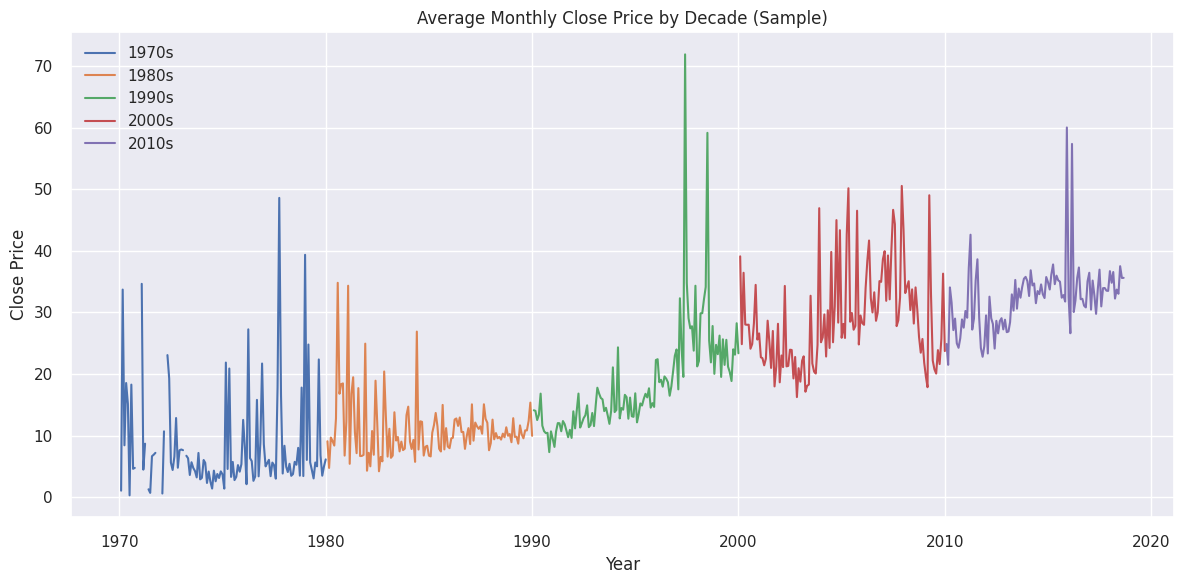

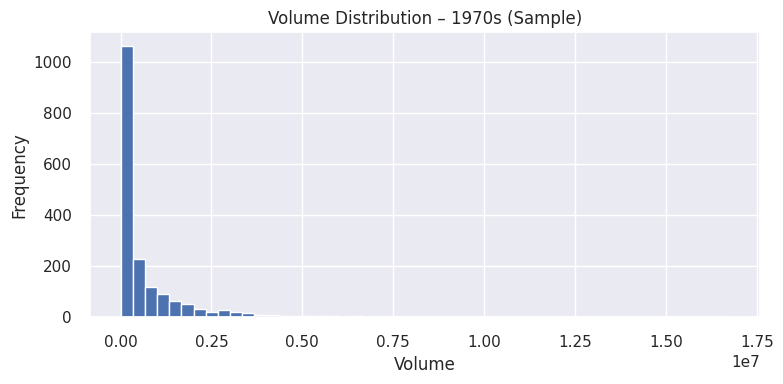

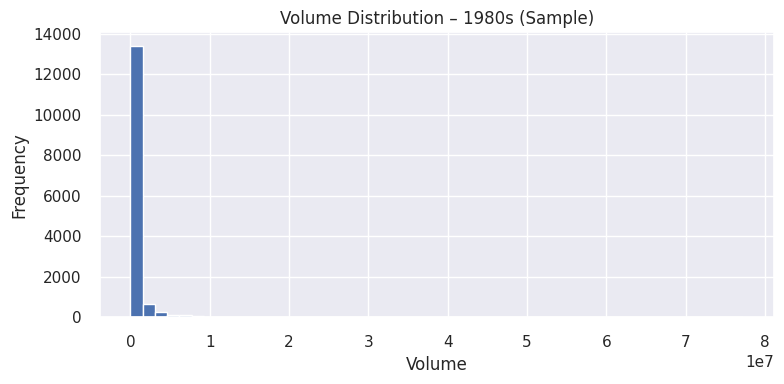

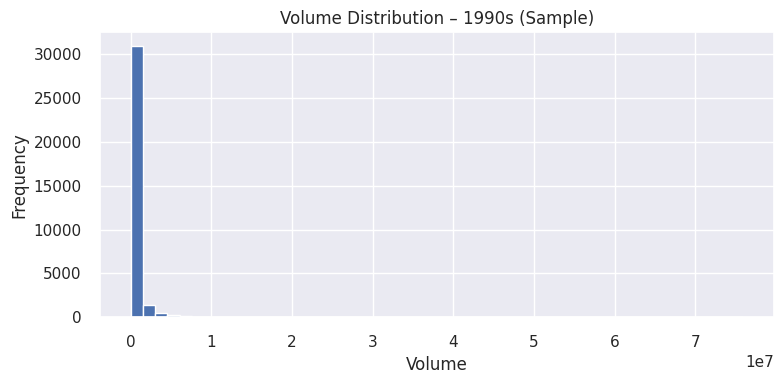

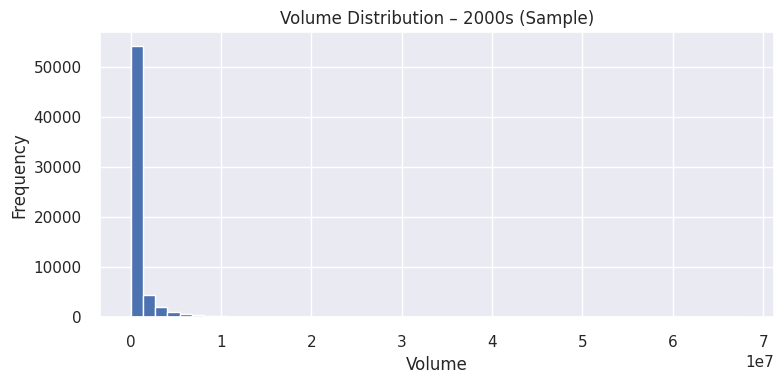

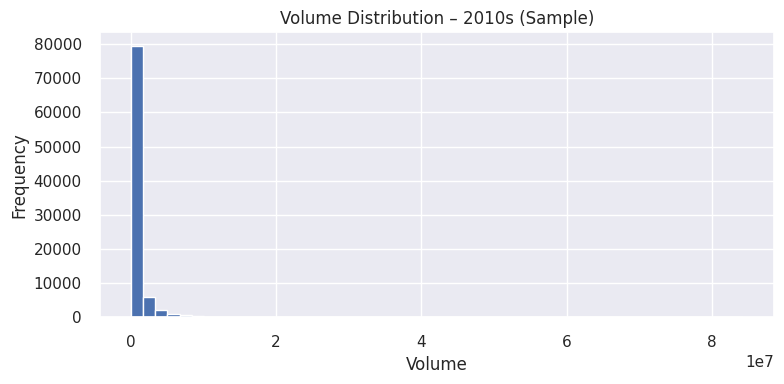

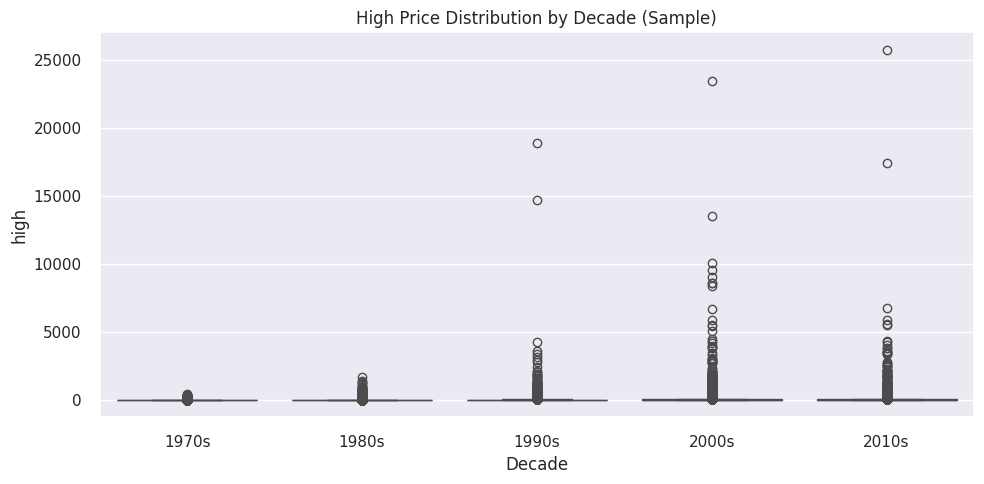

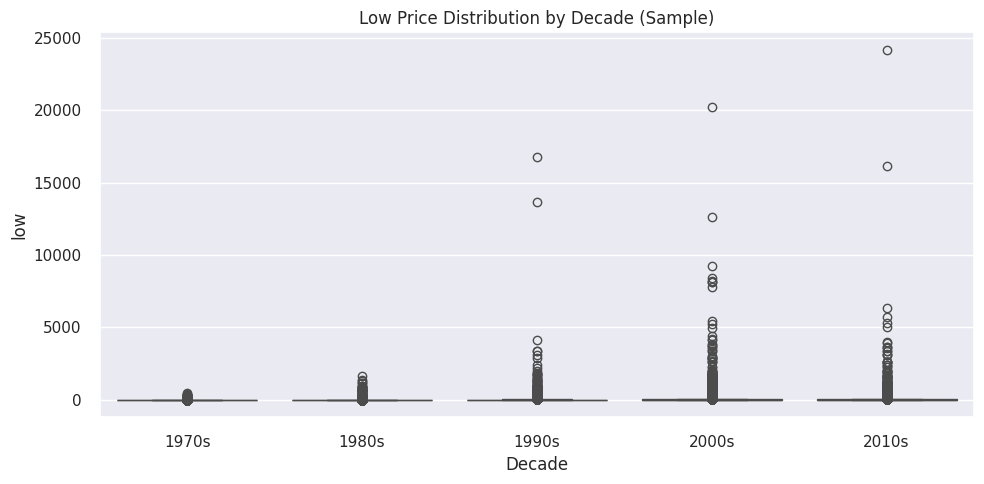


📊 Final decade comparison table:
        open_mean  open_median   open_std  high_mean   low_mean  close_mean  \
Decade                                                                        
1970s    7.345395     8.161875   4.422627   7.460699   7.272422    7.346027   
1980s   11.224474     5.671669  16.139315  11.389967  11.082929   11.223076   
1990s   19.781783    10.776230  44.625493  20.167861  19.397000   19.773738   
2000s   30.911218    16.663476  92.476588  31.581311  30.185351   30.867685   
2010s   32.725925    20.100250  63.312138  33.183839  32.248786   32.709433   

        close_median  close_std    volume_mean  volume_median    volume_std  \
Decade                                                                        
1970s       8.162065   4.424213  575258.785168  423795.250000  5.146907e+05   
1980s       5.669456  16.152519  617031.680754  101950.495238  1.300261e+06   
1990s      10.779435  44.551478  539286.264601   78800.000000  1.339318e+06   
2000s      16.665

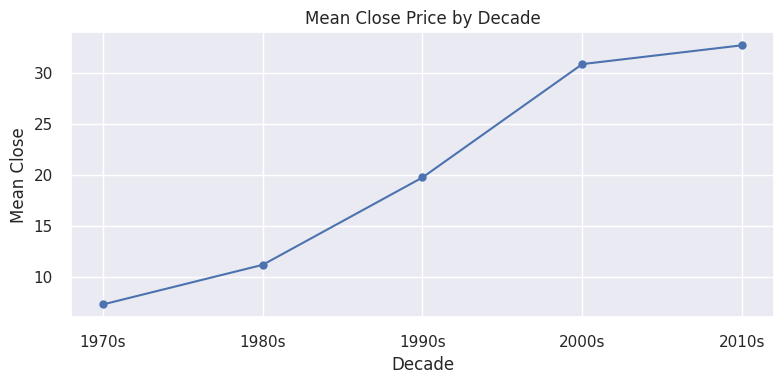

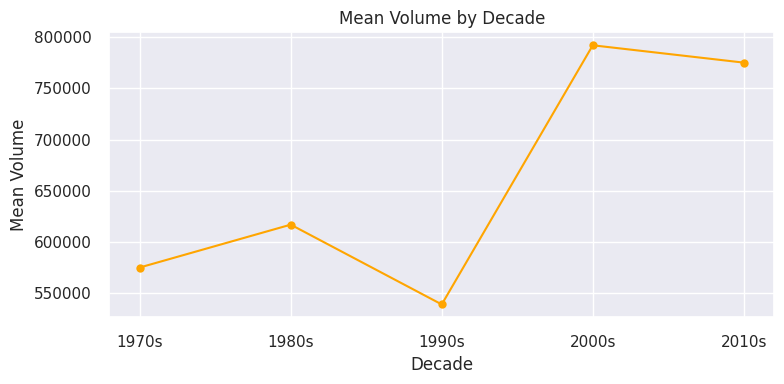


Modeling shapes (using sample):
Train: (142907, 4) 142907
Val:   (30623, 4) 30623
Test:  (30623, 4) 30623

✅ EDA, comparative analysis, and modeling prep completed (sample-based, memory-safe).


In [2]:
# ============================================================
# 📌 DECADE-LEVEL EDA + COMPARATIVE ANALYSIS + MODELING PREP
#    (Using cleaned chunks from clean_chunks)
# ============================================================

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8")
sns.set_theme()

# ============================================================
# 1. DISCOVER CLEANED CHUNKS
# ============================================================

files = glob.glob("clean_chunks/clean_chunk_*.csv")
print(f"Found {len(files)} cleaned chunks")

# ============================================================
# 2. BUILD DECADE-LEVEL SUMMARY (MEMORY-SAFE)
#    We aggregate stats per decade without loading everything.
# ============================================================

decade_stats_list = []

for f in files:
    df = pd.read_csv(f, usecols=["Decade", "open", "high", "low", "close", "volume"])
    grp = df.groupby("Decade").agg(
        open_mean=("open", "mean"),
        open_median=("open", "median"),
        open_std=("open", "std"),
        high_mean=("high", "mean"),
        low_mean=("low", "mean"),
        close_mean=("close", "mean"),
        close_median=("close", "median"),
        close_std=("close", "std"),
        volume_mean=("volume", "mean"),
        volume_median=("volume", "median"),
        volume_std=("volume", "std"),
        count=("close", "count")
    )
    decade_stats_list.append(grp)

decade_stats = pd.concat(decade_stats_list).groupby(level=0).mean()
print("\n📊 Decade-level summary statistics:")
print(decade_stats)

# ============================================================
# 3. BUILD A SAMPLE FOR PLOTTING (SAFE)
#    We take a small sample from each chunk to visualize.
# ============================================================

sample_list = []

for f in files:
    df = pd.read_csv(
        f,
        usecols=["date", "Decade", "close", "volume", "high", "low", "ticker"]
    )
    # small random sample per file
    sample_list.append(df.sample(frac=0.01, random_state=42))

sample = pd.concat(sample_list, ignore_index=True)
sample["date"] = pd.to_datetime(sample["date"])
sample = sample.sort_values("date")

print("\nSample shape for EDA:", sample.shape)

# ============================================================
# 4. EDA BY DECADE
# ============================================================

# 4.1 Time series: average monthly close per decade
plt.figure(figsize=(12, 6))
for dec, df_dec in sample.groupby("Decade"):
    monthly = df_dec.set_index("date")["close"].resample("M").mean()
    plt.plot(monthly.index, monthly.values, label=dec)

plt.title("Average Monthly Close Price by Decade (Sample)")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

# 4.2 Volume histograms per decade
for dec, df_dec in sample.groupby("Decade"):
    plt.figure(figsize=(8, 4))
    df_dec["volume"].hist(bins=50)
    plt.title(f"Volume Distribution – {dec} (Sample)")
    plt.xlabel("Volume")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 4.3 Boxplots for high/low by decade
plt.figure(figsize=(10, 5))
sns.boxplot(x="Decade", y="high", data=sample)
plt.title("High Price Distribution by Decade (Sample)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="Decade", y="low", data=sample)
plt.title("Low Price Distribution by Decade (Sample)")
plt.tight_layout()
plt.show()

# ============================================================
# 5. COMPARATIVE ANALYSIS PREP
# ============================================================

print("\n📊 Final decade comparison table:")
print(decade_stats)

# Example: simple trend view
decade_order = sorted(decade_stats.index)
plt.figure(figsize=(8, 4))
plt.plot(decade_order, decade_stats["close_mean"].values, marker="o")
plt.title("Mean Close Price by Decade")
plt.xlabel("Decade")
plt.ylabel("Mean Close")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(decade_order, decade_stats["volume_mean"].values, marker="o", color="orange")
plt.title("Mean Volume by Decade")
plt.xlabel("Decade")
plt.ylabel("Mean Volume")
plt.tight_layout()
plt.show()

# ============================================================
# 6. MODELING DATASET (ON A MANAGEABLE SUBSET)
#    We’ll use the sample for modeling to avoid RAM issues.
# ============================================================

# Simple target: next-day close (within sample)
sample = sample.sort_values("date")
sample["target_close_next"] = sample["close"].shift(-1)
sample = sample.dropna(subset=["target_close_next"])

# Select features
X = sample[["close", "volume", "high", "low"]].copy()
y = sample["target_close_next"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/val/test split (time-based)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, shuffle=False
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

print("\nModeling shapes (using sample):")
print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))

# ============================================================
# 7. SAVE MODELING DATA (OPTIONAL)
# ============================================================

np.save("X_train_sample.npy", X_train)
np.save("X_val_sample.npy", X_val)
np.save("X_test_sample.npy", X_test)
y_train.to_csv("y_train_sample.csv", index=False)
y_val.to_csv("y_val_sample.csv", index=False)
y_test.to_csv("y_test_sample.csv", index=False)

print("\n✅ EDA, comparative analysis, and modeling prep completed (sample-based, memory-safe).")

In [2]:
# Feature Engineering: MACD + RSI (Manual Implementation)
import pandas as pd
import numpy as np
import glob

# Helper functions
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def compute_macd(df):
    df["EMA12"] = ema(df["close"], 12)
    df["EMA26"] = ema(df["close"], 26)
    df["MACD"] = df["EMA12"] - df["EMA26"]
    df["Signal"] = ema(df["MACD"], 9)
    df["MACD_Buy"] = (df["MACD"] > df["Signal"]).astype(int)
    df["MACD_Sell"] = (df["MACD"] < df["Signal"]).astype(int)
    return df

def compute_rsi(df, period=14):
    delta = df["close"].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = ema(pd.Series(gain), period)
    avg_loss = ema(pd.Series(loss), period)
    RS = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + RS))
    df["RSI_Buy"] = (df["RSI"] < 30).astype(int)
    df["RSI_Sell"] = (df["RSI"] > 70).astype(int)
    return df

# Load cleaned chunks
files = glob.glob("clean_chunks/*.csv")
model_data = []

print("Processing cleaned chunks...")

for f in files:
    df = pd.read_csv(f)
    df = df.sort_values("date")

    # Compute indicators
    df = compute_macd(df)
    df = compute_rsi(df)

    # Final trading signal
    df["Signal_Label"] = 0
    df.loc[(df["MACD_Buy"] == 1) & (df["RSI_Buy"] == 1), "Signal_Label"] = 1
    df.loc[(df["MACD_Sell"] == 1) & (df["RSI_Sell"] == 1), "Signal_Label"] = -1

    # Keep only rows with valid indicators
    df = df.dropna(subset=["MACD", "Signal", "RSI"])

    # Append modeling rows
    model_data.append(df[[
        "close", "volume", "high", "low",
        "MACD", "Signal", "RSI", "Signal_Label"
    ]])

# Build final dataset
data = pd.concat(model_data, ignore_index=True)
print("Final modeling dataset shape:", data.shape)

Processing cleaned chunks...
Final modeling dataset shape: (20414838, 8)


In [5]:
# Prepare Data for Modeling
# ============================================================
# BUILD A SMALL, FAST MODELING SAMPLE
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Take a random sample of 20,000 rows (safe for Colab)
data_sample = data.sample(n=20000, random_state=42)

X = data_sample[["close", "volume", "high", "low", "MACD", "Signal", "RSI"]]
y = data_sample["Signal_Label"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=True, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16000, 7)
Test size: (4000, 7)


In [6]:
# Train Models (Logistic Regression, Random Forest, SVM)
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)

# 2. Random Forest (smaller number of trees)
rf = RandomForestClassifier(n_estimators=50, max_depth=10)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 3. SVM (linear kernel = MUCH faster)
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [7]:
# Evaluate Models
print("\n=== Logistic Regression ===")
print(classification_report(y_test, log_pred))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))

print("\n=== SVM (Linear) ===")
print(classification_report(y_test, svm_pred))



=== Logistic Regression ===
              precision    recall  f1-score   support

          -1       0.72      0.54      0.62        39
           0       1.00      1.00      1.00      3961

    accuracy                           0.99      4000
   macro avg       0.86      0.77      0.81      4000
weighted avg       0.99      0.99      0.99      4000


=== Random Forest ===
              precision    recall  f1-score   support

          -1       0.78      0.72      0.75        39
           0       1.00      1.00      1.00      3961

    accuracy                           1.00      4000
   macro avg       0.89      0.86      0.87      4000
weighted avg       1.00      1.00      1.00      4000


=== SVM (Linear) ===
              precision    recall  f1-score   support

          -1       0.70      0.54      0.61        39
           0       1.00      1.00      1.00      3961

    accuracy                           0.99      4000
   macro avg       0.85      0.77      0.80      4000
